# Multimodal Emotion Recognizer — v2 (fusão tardia compacta + K-Fold CV)

Reescrita completa do modelo/treino. Consome o cache **v2** (`cache_{dataset}_v2`), gerado pelo
`pre_processing_v2.ipynb`, onde cada modalidade é um vetor de **statistics pooling (mean ⊕ std)** —
ou seja, já carrega a dinâmica (prosódia/expressão), diferente do v1 que fazia só a média.

Princípios do redesenho (contra o overfit e o teto de ~0.60 de test-F1 do v1):
- **Modelo minúsculo e fortemente regularizado** (fusão tardia por atenção), não um Transformer de 4 camadas.
- **Padronização (z-score) das features por fold**, ajustada só no treino (sem vazamento).
- **Regularização pesada**: label smoothing, weight decay, ruído gaussiano, mixup, dropout de modalidade,
  supervisão profunda (cabeças auxiliares por modalidade) e early stopping.
- **Stratified K-Fold CV** → métrica estável (média ± desvio), no lugar de um único split ruidoso de ~90 amostras.
- **Treino 100% na CPU**: o modelo é minúsculo e as features estão em cache. Isso elimina de vez o
  DirectML (sem deadlock de threads, sem LayerNorm desligada) e permite rodar tudo em série sem travar.

## 1. Configuração

In [1]:
# ===================== CONTROLE DO EXPERIMENTO =====================
DATASET      = "pt"          # "en" ou "pt" -> caminho do cache v2
CLASS_MODES  = ["valence", "emotion7"]   # ["valence"], ["emotion7"] ou ["valence","emotion7"]
RUN_ABLATION = True          # True: roda todas as combinações de modalidades (001..111)
MODALITIES_IF_NO_ABLATION = ["text", "audio", "image"]  # usado quando RUN_ABLATION=False
# ==================================================================

CONFIG = {
    "hidden":            96,     # dimensão interna por modalidade (pequena de propósito)
    "dropout":           0.35,   # dropout dentro dos encoders/cabeça
    "modality_dropout":  0.20,   # chance de zerar uma modalidade inteira no treino (robustez à fusão)
    "aux_weight":        0.3,    # peso das cabeças unimodais (supervisão profunda)
    # augmentation no espaço de features
    "noise_std":         0.10,   # ruído gaussiano (× desvio, pós-padronização) no treino
    "mixup_alpha":       0.2,    # Beta(a,a); 0 desativa mixup
    "label_smoothing":   0.05,
    # otimização
    "batch_size":        32,
    "epochs":            120,
    "lr":                2e-3,
    "weight_decay":      5e-2,   # WD alto compensa o dataset pequeno
    "grad_clip":         1.0,
    "patience":          20,     # early stopping por F1-macro de validação
    # avaliação
    "n_folds":           5,
    "inner_val_ratio":   0.1765, # ~15% do total vira validação dentro de cada fold de treino
    "class_weighting":   True,
    "seed":              42,
}

# --- Modalidades e rótulos ---
MODALITIES  = ["text", "audio", "image"]              # ordem canônica
CACHE_FIELD = {"text": "text", "audio": "audio", "image": "image"}
EMOTION_NAMES_7 = ["Anger", "Disgust", "Fear", "Happy", "Neutral", "Sadness", "Surprised"]
EMOTION_VALENCE = {0: -1, 1: -1, 2: -1, 3: 1, 4: 0, 5: -1, 6: 1}  # label_id 0..6 -> -1/0/+1

CACHE_DIR      = f"../cache_{DATASET}_v2/multimodal"
CHECKPOINT_DIR = f"../checkpoints/{DATASET}_v2"

def class_setup(mode):
    if mode == "valence":
        names = ["Negative", "Neutral", "Positive"]
        remap = lambda lid: EMOTION_VALENCE[int(lid)] + 1
    elif mode == "emotion7":
        names = EMOTION_NAMES_7
        remap = lambda lid: int(lid)
    else:
        raise ValueError(mode)
    return names, len(names), remap

## 2. Imports e ambiente

In [2]:
import os, glob, random, copy, itertools, collections
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except ImportError:
    from tqdm import tqdm

# Treino na CPU de propósito: modelo minúsculo + features em cache. Evita o DirectML
# (deadlock com threads, LayerNorm sem backward) e garante execução determinística e estável.
device = torch.device("cpu")
torch.set_num_threads(max(1, (os.cpu_count() or 2)))

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

set_seed(CONFIG["seed"])
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"torch {torch.__version__} | device: {device} | threads: {torch.get_num_threads()}")

torch 2.7.1+cpu | device: cpu | threads: 12


c:\Users\luis-\Documents\codigos\academico\MultimodalEmotionReconizer\.venv-torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Carregamento do cache v2

Lê os `.pt` uma única vez. Cada arquivo tem `text/audio/image` (vetores mean⊕std) + `label` (0..6 original).
As dimensões de entrada são **inferidas do próprio cache** (robusto ao que o pré-processamento salvou).

In [3]:
def load_cache(cache_dir):
    files = sorted(glob.glob(os.path.join(cache_dir, "*.pt")))
    if not files:
        raise RuntimeError(
            f"Nenhum .pt em {cache_dir}. Gere o cache v2 com pre_processing_v2.ipynb "
            f"(variável dataset={DATASET})."
        )
    feats = {m: [] for m in MODALITIES}
    labels = []
    for fp in files:
        s = torch.load(fp, map_location="cpu", weights_only=False)
        for m in MODALITIES:
            feats[m].append(s[CACHE_FIELD[m]].float().numpy())
        labels.append(int(s["label"]))
    FEATS = {m: np.stack(feats[m]).astype(np.float32) for m in MODALITIES}
    Y7 = np.asarray(labels, dtype=np.int64)
    return files, FEATS, Y7

FILES, FEATS, Y7 = load_cache(CACHE_DIR)
IN_DIMS = {m: FEATS[m].shape[1] for m in MODALITIES}
N = len(Y7)
print(f"Amostras: {N}")
print("Dims por modalidade (in_dims):", IN_DIMS)
print("Distribuição (7 classes):",
      {EMOTION_NAMES_7[c]: int((Y7 == c).sum()) for c in range(7)})

def all_modality_combos():
    combos = []
    for r in range(1, len(MODALITIES) + 1):
        combos += [list(c) for c in itertools.combinations(MODALITIES, r)]
    return combos

def mask_str(active): return "".join("1" if m in active else "0" for m in MODALITIES)
def mod_label(active): return "+".join(active)

Amostras: 604
Dims por modalidade (in_dims): {'text': 1539, 'audio': 1536, 'image': 1536}
Distribuição (7 classes): {'Anger': 84, 'Disgust': 85, 'Fear': 88, 'Happy': 85, 'Neutral': 93, 'Sadness': 79, 'Surprised': 90}


## 4. Modelo — fusão tardia por atenção (compacta e regularizada)

Cada modalidade ativa passa por um encoder pequeno (LayerNorm → Linear → GELU → Dropout), vira um token,
e a fusão é uma média ponderada por atenção sobre os tokens. Cabeças auxiliares por modalidade dão
supervisão profunda. Construído **só para as modalidades ativas** (para a ablação).

In [4]:
class ModalityEncoder(nn.Module):
    def __init__(self, in_dim, hid, p):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(in_dim), nn.Dropout(p),
            nn.Linear(in_dim, hid), nn.GELU(),
            nn.LayerNorm(hid), nn.Dropout(p),
        )
    def forward(self, x): return self.net(x)


class AttnGatedFusion(nn.Module):
    """Fusão tardia: encoders por modalidade -> tokens -> atenção -> cabeça. Params ~ dezenas de k."""
    def __init__(self, in_dims, hid, num_classes, dropout, modality_dropout, aux_weight):
        super().__init__()
        self.mods = list(in_dims.keys())
        self.modality_dropout = modality_dropout
        self.aux_weight = aux_weight
        self.encoders = nn.ModuleDict({m: ModalityEncoder(in_dims[m], hid, dropout) for m in self.mods})
        self.gate = nn.Sequential(nn.Linear(hid, hid // 2), nn.GELU(), nn.Linear(hid // 2, 1))
        self.head = nn.Sequential(
            nn.LayerNorm(hid), nn.Dropout(dropout),
            nn.Linear(hid, hid // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hid // 2, num_classes),
        )
        self.aux = nn.ModuleDict({m: nn.Linear(hid, num_classes) for m in self.mods})

    def forward(self, inputs):
        reps = [self.encoders[m](inputs[m]) for m in self.mods]      # cada [B, hid]
        H = torch.stack(reps, dim=1)                                 # [B, M, hid]
        scores = self.gate(H).squeeze(-1)                            # [B, M]
        if self.training and self.modality_dropout > 0 and len(self.mods) > 1:
            keep = torch.rand(scores.shape, device=scores.device) > self.modality_dropout
            keep[~keep.any(dim=1), 0] = True                         # garante >=1 modalidade
            scores = scores.masked_fill(~keep, float("-inf"))
        w = torch.softmax(scores, dim=1)                            # [B, M]
        fused = (w.unsqueeze(-1) * H).sum(dim=1)                     # [B, hid]
        logits = self.head(fused)
        aux_logits = {m: self.aux[m](H[:, i]) for i, m in enumerate(self.mods)}
        return logits, aux_logits


def build_model(active, num_classes):
    in_dims = {m: IN_DIMS[m] for m in active}
    return AttnGatedFusion(in_dims, CONFIG["hidden"], num_classes,
                           CONFIG["dropout"], CONFIG["modality_dropout"], CONFIG["aux_weight"]).to(device)

## 5. Treino de um fold (com augmentation e early stopping)

In [5]:
def make_tensors(FEATS_std, y, idx, active):
    x = {m: torch.from_numpy(FEATS_std[m][idx]).to(device) for m in active}
    t = torch.from_numpy(y[idx]).to(device)
    return x, t

def iterate_minibatches(n, bs, shuffle, seed=0):
    order = np.arange(n)
    if shuffle:
        np.random.RandomState(seed).shuffle(order)
    for i in range(0, n, bs):
        yield order[i:i + bs]

def compute_metrics(y_true, y_pred, num_classes):
    labels = list(range(num_classes))
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=labels,
                                                  average="macro", zero_division=0)
    return {"acc": accuracy_score(y_true, y_pred), "precision": p, "recall": r, "f1_macro": f1}

def class_weights(y, num_classes):
    counts = np.bincount(y, minlength=num_classes).astype(np.float64)
    w = counts.sum() / (num_classes * np.maximum(counts, 1.0))
    return torch.tensor(w, dtype=torch.float32, device=device)

@torch.no_grad()
def predict(model, x, active, bs=256):
    model.eval()
    n = next(iter(x.values())).shape[0]
    out = []
    for i in range(0, n, bs):
        xb = {m: x[m][i:i + bs] for m in active}
        logits, _ = model(xb)
        out.append(logits.argmax(1).cpu())
    return torch.cat(out).numpy()

def train_fold(active, num_classes, X, y, tr_idx, va_idx, cfg, seed):
    """Treina em tr_idx, early-stopping por F1 de va_idx. Retorna melhor estado + val f1."""
    set_seed(seed)
    model = build_model(active, num_classes)
    cw = class_weights(y[tr_idx], num_classes) if cfg["class_weighting"] else None
    crit = nn.CrossEntropyLoss(weight=cw, label_smoothing=cfg["label_smoothing"])
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg["epochs"])

    x_tr, t_tr = make_tensors(X, y, tr_idx, active)
    x_va, t_va = make_tensors(X, y, va_idx, active)
    n_tr = len(tr_idx)
    best = {"f1": -1.0, "state": None, "epoch": -1}
    no_improve = 0

    for epoch in range(1, cfg["epochs"] + 1):
        model.train()
        for bi, bidx in enumerate(iterate_minibatches(n_tr, cfg["batch_size"], True, seed + epoch)):
            xb = {m: x_tr[m][bidx] for m in active}
            yb = t_tr[bidx]
            # ruído gaussiano (features já padronizadas -> std ~1)
            if cfg["noise_std"] > 0:
                xb = {m: v + cfg["noise_std"] * torch.randn_like(v) for m, v in xb.items()}
            # mixup no espaço de features
            use_mix = cfg["mixup_alpha"] > 0 and xb[active[0]].shape[0] > 1
            if use_mix:
                lam = float(np.random.beta(cfg["mixup_alpha"], cfg["mixup_alpha"]))
                perm = torch.randperm(yb.shape[0], device=device)
                xb = {m: lam * v + (1 - lam) * v[perm] for m, v in xb.items()}
                yb2 = yb[perm]
            logits, aux = model(xb)
            if use_mix:
                loss = lam * crit(logits, yb) + (1 - lam) * crit(logits, yb2)
                if cfg["aux_weight"] > 0 and len(active) > 1:
                    aux_l = sum(lam * crit(a, yb) + (1 - lam) * crit(a, yb2) for a in aux.values())
                    loss = loss + cfg["aux_weight"] * aux_l / len(active)
            else:
                loss = crit(logits, yb)
                if cfg["aux_weight"] > 0 and len(active) > 1:
                    loss = loss + cfg["aux_weight"] * sum(crit(a, yb) for a in aux.values()) / len(active)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            opt.step()
        sched.step()

        va_pred = predict(model, x_va, active)
        vf1 = compute_metrics(t_va.cpu().numpy(), va_pred, num_classes)["f1_macro"]
        if vf1 > best["f1"]:
            best = {"f1": vf1, "state": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
                    "epoch": epoch}
            no_improve = 0
        else:
            no_improve += 1
        if cfg["patience"] and no_improve >= cfg["patience"]:
            break

    model.load_state_dict(best["state"])
    return model, best["f1"], best["epoch"]

## 6. Cross-validation estratificada (métrica honesta)

Para cada um dos K folds externos: o fold é o **teste**; do restante separa-se uma **validação** interna
(early stopping) e treina-se no resto. A **padronização é ajustada só no treino** de cada fold.
Retorna métricas por fold + predições agregadas (para matriz de confusão global).

In [6]:
def standardize(FEATS, fit_idx, active):
    out = {}
    for m in active:
        sc = StandardScaler().fit(FEATS[m][fit_idx])
        out[m] = sc.transform(FEATS[m]).astype(np.float32)
    return out

def cross_validate(active, num_classes, remap, cfg, verbose=False):
    y = np.asarray([remap(l) for l in Y7], dtype=np.int64)
    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True, random_state=cfg["seed"])
    fold_metrics, all_true, all_pred = [], [], []

    for fold, (trainval_idx, test_idx) in enumerate(skf.split(np.zeros(N), y)):
        tr_idx, va_idx = train_test_split(
            trainval_idx, test_size=cfg["inner_val_ratio"], stratify=y[trainval_idx],
            random_state=cfg["seed"] + fold)
        # padroniza usando SÓ o treino do fold (sem vazamento p/ val/test)
        Xstd = standardize(FEATS, tr_idx, active)
        model, vf1, ep = train_fold(active, num_classes, Xstd, y, tr_idx, va_idx, cfg,
                                    seed=cfg["seed"] + fold)
        x_te, t_te = make_tensors(Xstd, y, test_idx, active)
        te_pred = predict(model, x_te, active)
        te_true = t_te.cpu().numpy()
        m = compute_metrics(te_true, te_pred, num_classes)
        m["val_f1"] = vf1; m["epoch"] = ep
        fold_metrics.append(m)
        all_true.append(te_true); all_pred.append(te_pred)
        if verbose:
            print(f"    fold {fold}: val_f1 {vf1:.3f} | test f1 {m['f1_macro']:.3f} "
                  f"acc {m['acc']:.3f} (ep {ep})")

    df = pd.DataFrame(fold_metrics)
    summary = {f"{k}_mean": float(df[k].mean()) for k in ["acc", "precision", "recall", "f1_macro"]}
    summary.update({f"{k}_std": float(df[k].std()) for k in ["f1_macro", "acc"]})
    return summary, np.concatenate(all_true), np.concatenate(all_pred), df

## 7. Execução — ablação de modalidades × modo de classe

In [7]:
def plot_confusion(y_true, y_pred, class_names, title=""):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
    ax.set_title(title); plt.tight_layout(); plt.show()

all_rows, best_conf = [], {}
combos = all_modality_combos() if RUN_ABLATION else [list(MODALITIES_IF_NO_ABLATION)]

for mode in CLASS_MODES:
    names, num_classes, remap = class_setup(mode)
    print(f"\n{'#'*70}\n# MODO: {mode}  ({num_classes} classes: {names})  | dataset={DATASET}\n{'#'*70}")
    for active in tqdm(combos, desc=f"ablação[{mode}]"):
        summary, ct, cp, df = cross_validate(active, num_classes, remap, CONFIG, verbose=True)
        row = {"dataset": DATASET, "mode": mode, "modalities": mod_label(active),
               "mask": mask_str(active), "n_classes": num_classes,
               "test_f1_macro": round(summary["f1_macro_mean"], 4),
               "test_f1_std": round(summary["f1_macro_std"], 4),
               "test_acc": round(summary["acc_mean"], 4),
               "val_f1_macro": round(float(df["val_f1"].mean()), 4)}
        all_rows.append(row)
        best_conf[(mode, mask_str(active))] = (ct, cp, names)
        print(f"  [{mask_str(active)}] {mod_label(active):18s} -> "
              f"test F1 {row['test_f1_macro']:.4f} ± {row['test_f1_std']:.4f} | acc {row['test_acc']:.4f}")

results = (pd.DataFrame(all_rows)
           .sort_values("val_f1_macro", ascending=False)
           .reset_index(drop=True))

_csv = os.path.join(CHECKPOINT_DIR, f"ablation_v2_{DATASET}.csv")
results.to_csv(_csv, index=False)
print(f"\nResultados salvos em: {_csv}")
results


######################################################################
# MODO: valence  (3 classes: ['Negative', 'Neutral', 'Positive'])  | dataset=pt
######################################################################


ablação[valence]:   0%|          | 0/7 [00:00<?, ?it/s]

    fold 0: val_f1 0.596 | test f1 0.555 acc 0.579 (ep 24)
    fold 1: val_f1 0.551 | test f1 0.482 acc 0.504 (ep 2)
    fold 2: val_f1 0.532 | test f1 0.513 acc 0.570 (ep 14)
    fold 3: val_f1 0.524 | test f1 0.487 acc 0.512 (ep 12)


ablação[valence]:  14%|█▍        | 1/7 [00:16<01:36, 16.05s/it]

    fold 4: val_f1 0.551 | test f1 0.567 acc 0.617 (ep 11)
  [100] text               -> test F1 0.5208 ± 0.0389 | acc 0.5564
    fold 0: val_f1 0.556 | test f1 0.510 acc 0.529 (ep 39)
    fold 1: val_f1 0.451 | test f1 0.531 acc 0.545 (ep 9)
    fold 2: val_f1 0.517 | test f1 0.494 acc 0.537 (ep 15)
    fold 3: val_f1 0.523 | test f1 0.544 acc 0.554 (ep 12)


...

ablação[emotion7]:  86%|████████▌ | 6/7 [02:01<00:22, 22.27s/it]

    fold 4: val_f1 0.450 | test f1 0.293 acc 0.308 (ep 6)
  [011] audio+image        -> test F1 0.3228 ± 0.0464 | acc 0.3394
    fold 0: val_f1 0.371 | test f1 0.315 acc 0.322 (ep 35)
    fold 1: val_f1 0.389 | test f1 0.340 acc 0.347 (ep 8)
    fold 2: val_f1 0.339 | test f1 0.424 acc 0.446 (ep 14)
    fold 3: val_f1 0.379 | test f1 0.294 acc 0.347 (ep 3)


ablação[emotion7]: 100%|██████████| 7/7 [02:41<00:00, 23.09s/it]

    fold 4: val_f1 0.495 | test f1 0.334 acc 0.350 (ep 40)
  [111] text+audio+image   -> test F1 0.3414 ± 0.0494 | acc 0.3626

Resultados salvos em: ../checkpoints/pt_v2\ablation_v2_pt.csv


,dataset,mode,modalities,mask,n_classes,test_f1_macro,test_f1_std,test_acc,val_f1_macro
0,pt,valence,text+image,101,3,0.6235,0.0475,0.6508,0.6985
1,pt,valence,text+audio+image,111,3,0.6320,0.0556,0.6458,0.6669
2,pt,valence,audio+image,011,3,0.6187,0.0541,0.6356,0.6664
3,pt,valence,image,001,3,0.5723,0.0385,0.5977,0.6611
4,pt,valence,text+audio,110,3,0.5599,0.0377,0.5845,0.5734
5,pt,valence,text,100,3,0.5208,0.0389,0.5564,0.5507
6,pt,valence,audio,010,3,0.5069,0.0347,0.5331,0.5117
7,pt,emotion7,audio+image,011,7,0.3228,0.0464,0.3394,0.3958
8,pt,emotion7,text+audio+image,111,7,0.3414,0.0494,0.3626,0.3949
9,pt,emotion7,text+image,101,7,0.3214,0.0362,0.3477,0.3858


## 8. Gráficos e matrizes de confusão (agregadas nos K folds)

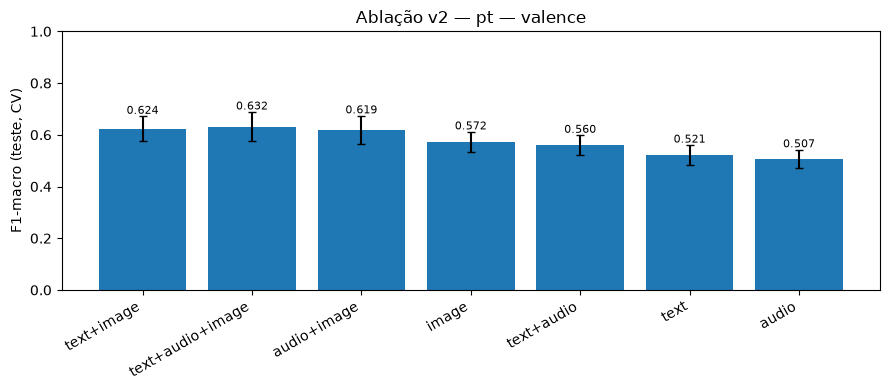

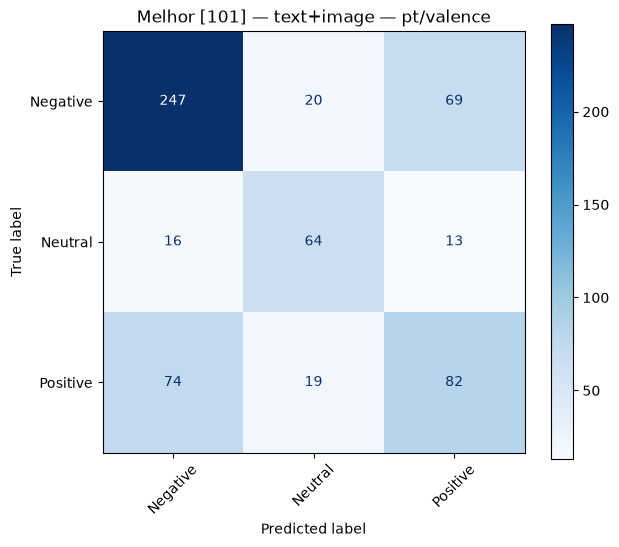

[valence] melhor: text+image (F1 0.6235 ± 0.0475)
              precision    recall  f1-score   support

    Negative       0.73      0.74      0.73       336
     Neutral       0.62      0.69      0.65        93
    Positive       0.50      0.47      0.48       175

    accuracy                           0.65       604
   macro avg       0.62      0.63      0.62       604
weighted avg       0.65      0.65      0.65       604



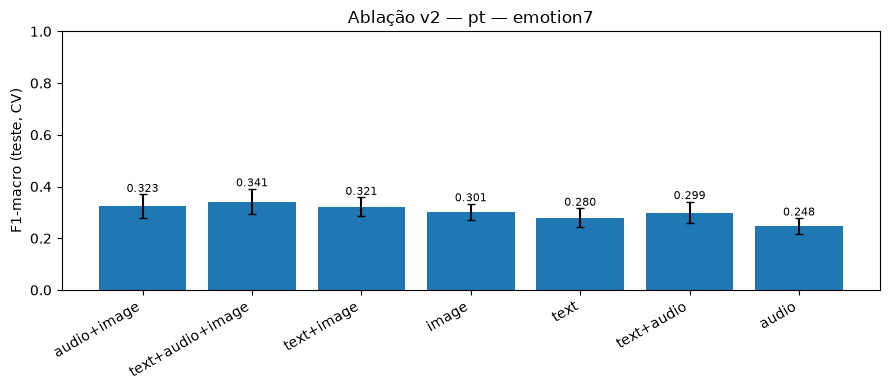

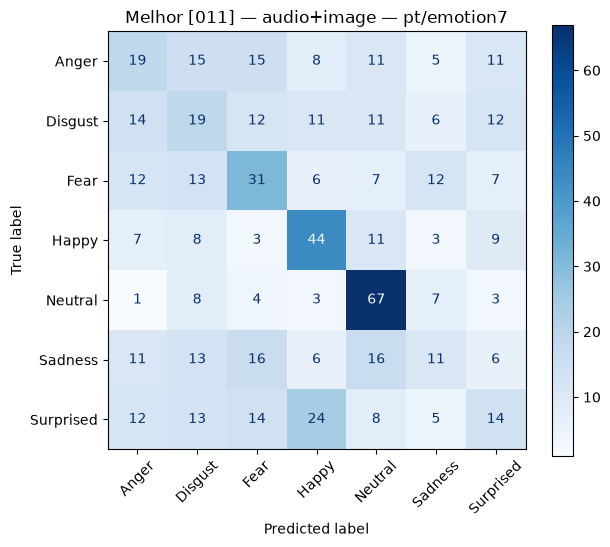

[emotion7] melhor: audio+image (F1 0.3228 ± 0.0464)
              precision    recall  f1-score   support

       Anger       0.25      0.23      0.24        84
     Disgust       0.21      0.22      0.22        85
        Fear       0.33      0.35      0.34        88
       Happy       0.43      0.52      0.47        85
     Neutral       0.51      0.72      0.60        93
     Sadness       0.22      0.14      0.17        79
   Surprised       0.23      0.16      0.18        90

    accuracy                           0.34       604
   macro avg       0.31      0.33      0.32       604
weighted avg       0.31      0.34      0.32       604



In [8]:
for mode in CLASS_MODES:
    sub = results[results["mode"] == mode].reset_index(drop=True)
    if len(sub) > 1:
        fig, ax = plt.subplots(figsize=(9, 4))
        xs = range(len(sub))
        ax.bar(xs, sub["test_f1_macro"], yerr=sub["test_f1_std"], capsize=3)
        ax.set_xticks(list(xs)); ax.set_xticklabels(sub["modalities"], rotation=30, ha="right")
        ax.set_ylabel("F1-macro (teste, CV)"); ax.set_ylim(0, 1)
        ax.set_title(f"Ablação v2 — {DATASET} — {mode}")
        for i, (v, e) in enumerate(zip(sub["test_f1_macro"], sub["test_f1_std"])):
            ax.text(i, v + e + 0.01, f"{v:.3f}", ha="center", fontsize=8)
        plt.tight_layout(); plt.show()

    # matriz de confusão da MELHOR combinação do modo
    best_mask = sub.iloc[0]["mask"]
    ct, cp, names = best_conf[(mode, best_mask)]
    plot_confusion(ct, cp, names,
                   f"Melhor [{best_mask}] — {sub.iloc[0]['modalities']} — {DATASET}/{mode}")
    print(f"[{mode}] melhor: {sub.iloc[0]['modalities']} "
          f"(F1 {sub.iloc[0]['test_f1_macro']:.4f} ± {sub.iloc[0]['test_f1_std']:.4f})")
    print(classification_report(ct, cp, target_names=names, zero_division=0))

## 9. Modelo final (treina em todos os dados e salva checkpoint)

Depois de escolher a melhor combinação pela CV, retreina em 100% dos dados (com uma val interna
só para early stopping) e salva o checkpoint para inferência.

In [9]:
def train_final(active, mode):
    names, num_classes, remap = class_setup(mode)
    y = np.asarray([remap(l) for l in Y7], dtype=np.int64)
    tr_idx, va_idx = train_test_split(np.arange(N), test_size=CONFIG["inner_val_ratio"],
                                      stratify=y, random_state=CONFIG["seed"])
    Xstd = standardize(FEATS, tr_idx, active)
    model, vf1, ep = train_fold(active, num_classes, Xstd, y, tr_idx, va_idx, CONFIG, seed=CONFIG["seed"])
    scalers = {m: StandardScaler().fit(FEATS[m][tr_idx]) for m in active}
    ckpt = os.path.join(CHECKPOINT_DIR, f"final_{DATASET}_{mode}_{mask_str(active)}.pt")
    torch.save({"model_state": model.state_dict(), "active": active, "mode": mode,
                "num_classes": num_classes, "in_dims": {m: IN_DIMS[m] for m in active},
                "class_names": names, "val_f1": vf1,
                "scaler_mean": {m: scalers[m].mean_ for m in active},
                "scaler_scale": {m: scalers[m].scale_ for m in active}}, ckpt)
    print(f"[final {mode}] {mod_label(active)} val_f1 {vf1:.4f} (ep {ep}) -> {ckpt}")
    return model

for mode in CLASS_MODES:
    sub = results[results["mode"] == mode].reset_index(drop=True)
    best_active = [m for m in MODALITIES if m in sub.iloc[0]["modalities"].split("+")]
    train_final(best_active, mode)

print("\nConcluído.")

[final valence] text+image val_f1 0.6702 (ep 9) -> ../checkpoints/pt_v2\final_pt_valence_101.pt
[final emotion7] audio+image val_f1 0.3672 (ep 7) -> ../checkpoints/pt_v2\final_pt_emotion7_011.pt

Concluído.
